In [2]:
# Import Libraries
import os
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ['TF_CPP_MIN_LOG_LEVEL'] = "2" 
import cv2
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

In [3]:
# Configuration
IMG_SIZE = 128  
DATA_PATH = "../Data/Scores"
BATCH_SIZE = 32
EPOCHS = 20  
LEARNING_RATE = 0.001

In [4]:
# Load Dataset
X, y, class_names = [], [], []
class_map = {}

print("[INFO] Loading dataset...")

for shape_name in os.listdir(DATA_PATH): 
    shape_path = os.path.join(DATA_PATH, shape_name)
    if not os.path.isdir(shape_path):
        continue
    
    for score in os.listdir(shape_path): 
        score_path = os.path.join(shape_path, score)
        if not os.path.isdir(score_path):
            continue
        
        label = f"{shape_name}_{score}"
        if label not in class_map:
            class_map[label] = len(class_map)
            class_names.append(label)
        
        for file in os.listdir(score_path):
            if file.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".tiff", ".jfif", ".webp")):
                path = os.path.join(score_path, file)
                img = cv2.imread(path)
                if img is None:
                    continue
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  
                X.append(img)
                y.append(class_map[label])

X = np.array(X, dtype="float32") / 255.0
y = np.array(y)

print(f"[INFO] Dataset loaded: {X.shape[0]} samples, {len(class_map)} classes")
print(f"[INFO] Classes: {class_names}")

[INFO] Loading dataset...
[INFO] Dataset loaded: 4298 samples, 34 classes
[INFO] Classes: ['Triangle_0', 'Triangle_4', 'Triangle_5', 'Star_3', 'Star_2', 'Star_0', 'Star_4', 'Star_5', 'Wave_3', 'Wave_2', 'Wave_0', 'Wave_4', 'Circle_3', 'Circle_2', 'Circle_0', 'Circle_4', 'Square_0', 'Square_4', 'Square_5', 'Overlapped pencils_3', 'Overlapped pencils_2', 'Overlapped pencils_0', 'Overlapped pencils_4', 'Overlapped pencils_6', 'Overlapped pencils_5', 'Overlapped circle_2', 'Overlapped circle_0', 'Overlapped circle_4', 'Overlapped circle_6', 'Overlapped circle_5', 'Diagonal_3', 'Diagonal_0', 'Diagonal_4', 'Diagonal_5']


In [6]:
# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [7]:
# Convert to categorical
num_classes = len(class_map)
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

print(f"[INFO] Train: {X_train.shape}, Test: {X_test.shape}")
print(f"[INFO] Number of classes: {num_classes}")

[INFO] Train: (3438, 128, 128, 3), Test: (860, 128, 128, 3)
[INFO] Number of classes: 34


In [8]:
# Enhanced Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=False,
    fill_mode='nearest',
    brightness_range=[0.8, 1.2]
)

In [11]:
# Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

In [9]:
# Build Optimized MobileNetV2 Model
print("[INFO] Building MobileNetV2...")

base_model = MobileNetV2(
    include_top=False,
    weights='imagenet',  # Use pre-trained weights
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

[INFO] Building MobileNetV2...


2025-10-14 13:25:59.691456: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [10]:
# Fine-tune from this layer onwards
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

In [11]:
# Compile with better optimizer
optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 34)             │        17,442 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,938,466 (11.21 MB)

 Trainable params: 2,538,338 (9.68 MB)

 Non-trainable params: 400,128 (1.53 MB)

In [12]:
# Callbacks
callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        './best_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

In [14]:
# Train model
print("[INFO] Training MobileNetV2...")
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

[INFO] Training MobileNetV2...
Epoch 1/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step - accuracy: 0.1442 - loss: 3.7212 
Epoch 1: val_accuracy improved from -inf to 0.16047, saving model to ./best_model.h5


108/108 ━━━━━━━━━━━━━━━━━━━━ 37s 299ms/step - accuracy: 0.1447 - loss: 3.7164 - val_accuracy: 0.1605 - val_loss: 4.6518 - learning_rate: 0.0010
Epoch 2/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - accuracy: 0.2610 - loss: 2.6722 
Epoch 2: val_accuracy improved from 0.16047 to 0.40233, saving model to ./best_model.h5


108/108 ━━━━━━━━━━━━━━━━━━━━ 32s 294ms/step - accuracy: 0.2610 - loss: 2.6719 - val_accuracy: 0.4023 - val_loss: 2.5137 - learning_rate: 0.0010
Epoch 3/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - accuracy: 0.2678 - loss: 2.5534 
Epoch 3: val_accuracy improved from 0.40233 to 0.54419, saving model to ./best_model.h5


108/108 ━━━━━━━━━━━━━━━━━━━━ 31s 289ms/step - accuracy: 0.2679 - loss: 2.5531 - val_accuracy: 0.5442 - val_loss: 2.1049 - learning_rate: 0.0010
Epoch 4/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.2882 - loss: 2.4000 
Epoch 4: val_accuracy did not improve from 0.54419
108/108 ━━━━━━━━━━━━━━━━━━━━ 32s 296ms/step - accuracy: 0.2882 - loss: 2.4000 - val_accuracy: 0.4198 - val_loss: 3.6790 - learning_rate: 0.0010
Epoch 5/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 0.2946 - loss: 2.3582 
Epoch 5: val_accuracy did not improve from 0.54419
108/108 ━━━━━━━━━━━━━━━━━━━━ 31s 290ms/step - accuracy: 0.2946 - loss: 2.3582 - val_accuracy: 0.4616 - val_loss: 5.2557 - learning_rate: 0.0010
Epoch 6/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - accuracy: 0.2767 - loss: 2.3657 
Epoch 6: val_accuracy did not improve from 0.54419
108/108 ━━━━━━━━━━━━━━━━━━━━ 32s 291ms/step - accuracy: 0.2768 - loss: 2.3657 - val_accuracy: 0.4430 - val_loss: 3.5832 - learning_rate: 0.0010
Epoc

108/108 ━━━━━━━━━━━━━━━━━━━━ 32s 299ms/step - accuracy: 0.3218 - loss: 2.1917 - val_accuracy: 0.5453 - val_loss: 3.3527 - learning_rate: 5.0000e-04
Epoch 10/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - accuracy: 0.3206 - loss: 2.1557 
Epoch 10: val_accuracy improved from 0.54535 to 0.56047, saving model to ./best_model.h5


108/108 ━━━━━━━━━━━━━━━━━━━━ 32s 294ms/step - accuracy: 0.3206 - loss: 2.1560 - val_accuracy: 0.5605 - val_loss: 2.4925 - learning_rate: 5.0000e-04
Epoch 11/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step - accuracy: 0.3070 - loss: 2.2181 
Epoch 11: val_accuracy improved from 0.56047 to 0.64535, saving model to ./best_model.h5


108/108 ━━━━━━━━━━━━━━━━━━━━ 32s 297ms/step - accuracy: 0.3071 - loss: 2.2179 - val_accuracy: 0.6453 - val_loss: 1.8842 - learning_rate: 5.0000e-04
Epoch 12/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 0.3032 - loss: 2.1952 
Epoch 12: val_accuracy did not improve from 0.64535
108/108 ━━━━━━━━━━━━━━━━━━━━ 31s 289ms/step - accuracy: 0.3032 - loss: 2.1951 - val_accuracy: 0.6163 - val_loss: 1.6249 - learning_rate: 5.0000e-04
Epoch 13/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - accuracy: 0.2936 - loss: 2.1872 
Epoch 13: val_accuracy did not improve from 0.64535
108/108 ━━━━━━━━━━━━━━━━━━━━ 32s 295ms/step - accuracy: 0.2937 - loss: 2.1872 - val_accuracy: 0.6256 - val_loss: 1.6739 - learning_rate: 5.0000e-04
Epoch 14/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 0.3098 - loss: 2.1450 
Epoch 14: val_accuracy did not improve from 0.64535
108/108 ━━━━━━━━━━━━━━━━━━━━ 31s 289ms/step - accuracy: 0.3099 - loss: 2.1452 - val_accuracy: 0.6186 - val_loss: 1.7943 - learning

108/108 ━━━━━━━━━━━━━━━━━━━━ 32s 297ms/step - accuracy: 0.2961 - loss: 2.1843 - val_accuracy: 0.6733 - val_loss: 1.1892 - learning_rate: 5.0000e-04
Epoch 17/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - accuracy: 0.3393 - loss: 2.1205 
Epoch 17: val_accuracy did not improve from 0.67326
108/108 ━━━━━━━━━━━━━━━━━━━━ 32s 293ms/step - accuracy: 0.3392 - loss: 2.1205 - val_accuracy: 0.5605 - val_loss: 1.2986 - learning_rate: 5.0000e-04
Epoch 18/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.3527 - loss: 2.0558 
Epoch 18: val_accuracy did not improve from 0.67326
108/108 ━━━━━━━━━━━━━━━━━━━━ 33s 307ms/step - accuracy: 0.3526 - loss: 2.0561 - val_accuracy: 0.6023 - val_loss: 1.4208 - learning_rate: 5.0000e-04
Epoch 19/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step - accuracy: 0.3185 - loss: 2.1607 
Epoch 19: val_accuracy did not improve from 0.67326
108/108 ━━━━━━━━━━━━━━━━━━━━ 35s 319ms/step - accuracy: 0.3186 - loss: 2.1602 - val_accuracy: 0.5640 - val_loss: 1.7258 - learning

In [15]:
# Evaluate model
print("[INFO] Evaluating model...")
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"\n[RESULT] Test Accuracy: {test_accuracy:.4f}")
print(f"[RESULT] Test Loss: {test_loss:.4f}")

[INFO] Evaluating model...
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 135ms/step - accuracy: 0.6979 - loss: 1.0734

[RESULT] Test Accuracy: 0.6733
[RESULT] Test Loss: 1.1892


In [16]:
# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 160ms/step 


In [17]:
# Classification Report
print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred_classes,
    labels=np.arange(num_classes),
    target_names=class_names,
    zero_division=0
))


Classification Report:
                      precision    recall  f1-score   support

          Triangle_0       0.00      0.00      0.00         0
          Triangle_4       0.00      0.00      0.00         8
          Triangle_5       0.93      0.95      0.94       119
              Star_3       0.30      0.47      0.37        19
              Star_2       0.00      0.00      0.00         2
              Star_0       0.00      0.00      0.00         3
              Star_4       0.51      0.54      0.52        50
              Star_5       0.00      0.00      0.00        24
              Wave_3       0.00      0.00      0.00        23
              Wave_2       0.00      0.00      0.00         2
              Wave_0       0.00      0.00      0.00         0
              Wave_4       0.57      0.99      0.72       103
            Circle_3       0.00      0.00      0.00        15
            Circle_2       0.00      0.00      0.00         0
            Circle_0       0.00      0.00    

In [18]:
# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_true, y_pred_classes)
print(cm)


Confusion Matrix:
[[  0   7   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   1]
 [  0 113   0   0   0   1   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   5]
 [  0   0   9   0   0   6   0   0   0   1   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   3]
 [  0   0   1   0   0   1   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0]
 [  0   0   1   0   0   1   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   1]
 [  0   0  14   0   0  27   0   4   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   5]
 [  0   0   5   0   0  17   0   1   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   1]
 [  0   0   0   0   0   0   0   0   0  23   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   2   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0]


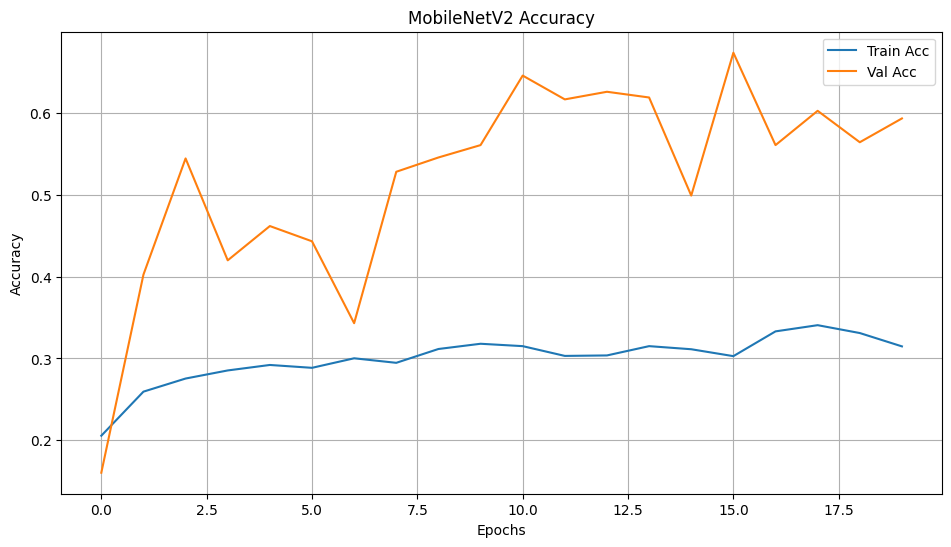

In [31]:
# Plot accuracy
plt.figure(figsize=(25, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('MobileNetV2 Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

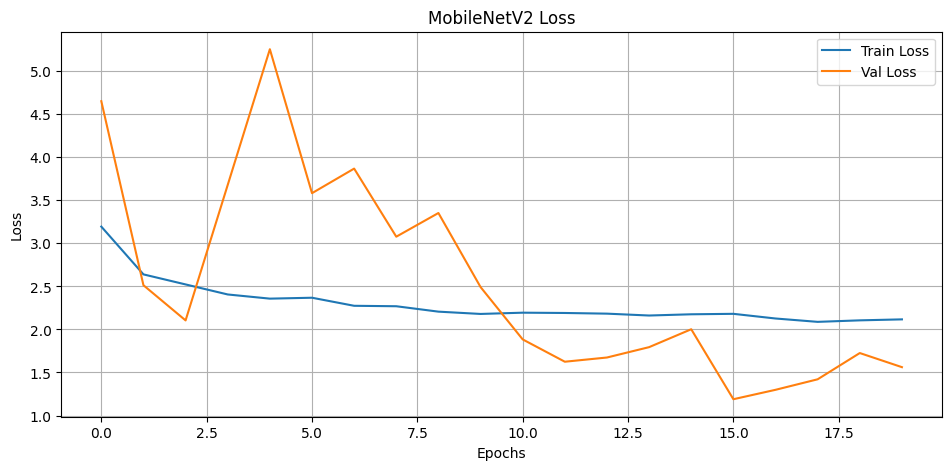

In [32]:
# Plot Loss
plt.figure(figsize=(25, 5))
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('MobileNetV2 Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

In [20]:
# Save Model
SAVE_DIR = "./model_outputs/mobileNetV2"
os.makedirs(SAVE_DIR, exist_ok=True)

In [26]:
# Accuracy Plot
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training & Validation Accuracy (mobileNetV2)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(SAVE_DIR, "accuracy_plot.png"))
plt.close()

In [25]:
# Save Loss Plot
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training & Validation Loss (mobileNetV2)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(SAVE_DIR, "loss_plot.png"))
plt.close()

In [24]:
# Save trained model
model.save(os.path.join(SAVE_DIR, "mobileNetV2_model.h5"))
print("[INFO] Model saved successfully")

[INFO] Model saved successfully


In [23]:
# Save training history as JSON
with open(os.path.join(SAVE_DIR, "training_history_mobileNetV2.json"), "w") as f:
    json.dump(history.history, f)
print("[INFO] Training history saved as JSON")

[INFO] Training history saved as JSON


In [22]:
# Save
pd.DataFrame(history.history).to_csv(os.path.join(SAVE_DIR, "global_mobileNetV2_training_history.csv"), index=False)

In [21]:
# Save classification report
report_dict = classification_report(
    y_true, 
    y_pred_classes,
    labels=np.arange(num_classes),
    target_names=class_names,
    zero_division=0,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv(os.path.join(SAVE_DIR, "classification_report.csv"))